In [1]:
import numpy as np
import plotly.graph_objects as go

# ── Chinchilla constants (Hoffmann et al. 2022, Table A9, Approach 3) ─────────
A = 406.4
alpha = 0.3392
B = 410.7
beta = 0.2849
E = 1.6934

# ── Swap these ────────────────────────────────────────────────────────────────
N1 = 125e6  # params, model 1
N2 = 500e6  # params, model 2

D1 = 1e8   # token sweep start
D2 = 100e9  # token sweep end

N_POINTS = 500
# ─────────────────────────────────────────────────────────────────────────────


def chinchilla_loss(N, D):
    return A / N**alpha + B / D**beta + E


def fmt_params(n):
    if n >= 1e9:
        return f"{n/1e9:.3g}B"
    if n >= 1e6:
        return f"{n/1e6:.3g}M"
    return str(n)


# ── Compute curves ────────────────────────────────────────────────────────────
D_range = np.logspace(np.log10(D1), np.log10(D2), N_POINTS)

C1 = 6 * N1 * D_range
L1 = chinchilla_loss(N1, D_range)

C2 = 6 * N2 * D_range
L2 = chinchilla_loss(N2, D_range)

# ── Chinchilla-opt for N1 ─────────────────────────────────────────────────────
D_opt1 = 20 * N1
C_opt1 = 6 * N1 * D_opt1
L_opt1 = chinchilla_loss(N1, D_opt1)

# ── Equivalent point on N2 at the same loss ───────────────────────────────────
# Solve A/N2**α + B/D_eq**β + E = L_opt1  →  D_eq = (B / (L_opt1 - E - A/N2**α))^(1/β)
D_eq2 = (B / (L_opt1 - E - A / N2**alpha)) ** (1 / beta)
C_eq2 = 6 * N2 * D_eq2
L_eq2 = chinchilla_loss(N2, D_eq2)

delta_C = C_eq2 - C_opt1

# ── Chinchilla-opt for N2 (independent marker) ────────────────────────────────
D_opt2 = 20 * N2
C_opt2 = 6 * N2 * D_opt2
L_opt2 = chinchilla_loss(N2, D_opt2)

# ── Colors ────────────────────────────────────────────────────────────────────
COLOR1 = "#58a6ff"
COLOR2 = "#f78166"
MUTED  = "#8b949e"
BG     = "#0d1117"
TEXT   = "#e6edf3"
GRID   = "#21262d"

# ── Build figure ──────────────────────────────────────────────────────────────
fig = go.Figure()

# Loss curves
fig.add_trace(go.Scatter(
    x=C1, y=L1, mode="lines", name=f"N = {fmt_params(N1)}",
    line=dict(color=COLOR1, width=2.5),
    hovertemplate="C = %{x:.3e}<br>L = %{y:.4f}<extra>N={fmt_params(N1)}</extra>",
))
fig.add_trace(go.Scatter(
    x=C2, y=L2, mode="lines", name=f"N = {fmt_params(N2)}",
    line=dict(color=COLOR2, width=2.5),
    hovertemplate="C = %{x:.3e}<br>L = %{y:.4f}<extra>N={fmt_params(N2)}</extra>",
))

# Chinchilla-opt marker — N1
fig.add_trace(go.Scatter(
    x=[C_opt1], y=[L_opt1], mode="markers",
    name=f"Chinchilla-opt N1  (D={fmt_params(D_opt1)})",
    marker=dict(color=COLOR1, size=11, line=dict(color="white", width=1.5)),
    hovertemplate=f"Chinchilla-opt N1<br>C = %{{x:.3e}}<br>L = %{{y:.4f}}<br>D = {fmt_params(D_opt1)}<extra></extra>",
))

# Horizontal dashed line at L_opt1
fig.add_shape(
    type="line",
    x0=C_opt1, x1=C_eq2, y0=L_opt1, y1=L_opt1,
    line=dict(color=COLOR1, width=1.5, dash="dot"),
)

# Equivalent point on N2
fig.add_trace(go.Scatter(
    x=[C_eq2], y=[L_eq2], mode="markers",
    name=f"Equivalent on N2  (D={fmt_params(D_eq2)})",
    marker=dict(color=COLOR2, size=11, symbol="diamond", line=dict(color="white", width=1.5)),
    hovertemplate=f"Equivalent on N2<br>C = %{{x:.3e}}<br>L = %{{y:.4f}}<br>D = {fmt_params(D_eq2)}<extra></extra>",
))

# Chinchilla-opt marker — N2
fig.add_trace(go.Scatter(
    x=[C_opt2], y=[L_opt2], mode="markers",
    name=f"Chinchilla-opt N2  (D={fmt_params(D_opt2)})",
    marker=dict(color=COLOR2, size=11, line=dict(color="white", width=1.5)),
    hovertemplate=f"Chinchilla-opt N2<br>C = %{{x:.3e}}<br>L = %{{y:.4f}}<br>D = {fmt_params(D_opt2)}<extra></extra>",
))

# ΔCompute annotation between the two horizontal points
x_mid = np.sqrt(C_opt1 * C_eq2)  # geometric mean looks better on log axis
# fig.add_annotation(
#     x=np.log10(x_mid), y=L_opt1 + 0.04,
#     xref="x", yref="y",
#     text=f"<b>ΔC = {delta_C:.3e} FLOPs</b><br>({C_eq2/C_opt1:.2f}× more compute for N2)",
#     showarrow=False,
#     font=dict(color=TEXT, size=11),
#     bgcolor="rgba(13,17,23,0.75)",
#     bordercolor=COLOR1,
#     borderwidth=1,
#     borderpad=5,
# )

# Irreducible floor
fig.add_hline(
    y=E, line=dict(color=MUTED, width=1, dash="dash"),
    annotation_text=f"irreducible floor  E = {E}",
    annotation_font_color=MUTED,
    annotation_position="bottom right",
)

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    title=dict(text="Loss vs Compute — Chinchilla Scaling", font=dict(size=15, color=TEXT)),
    xaxis=dict(
        type="log",
        title="Compute  C = 6·N·D  (FLOPs)",
        gridcolor=GRID, showgrid=True, minor=dict(showgrid=True, gridcolor=GRID),
        tickformat=".0e",
    ),
    yaxis=dict(
        title="Chinchilla Loss  L(N, D)",
        gridcolor=GRID, showgrid=True,
        tickformat=".2f",
    ),
    legend=dict(bgcolor="rgba(0,0,0,0.4)", bordercolor=GRID, borderwidth=1),
    hovermode="closest",
    width=950, height=580,
)

fig.show()

print(f"\nChinchilla-opt  N1 : C = {C_opt1:.3e} FLOPs,  L = {L_opt1:.4f},  D = {fmt_params(D_opt1)}")
print(f"Equivalent on   N2 : C = {C_eq2:.3e} FLOPs,  L = {L_eq2:.4f},  D = {fmt_params(D_eq2)}")
print(f"\nΔ Compute          : {delta_C:.3e} FLOPs  ({C_eq2/C_opt1:.2f}× more compute needed for N2 to reach the same loss)")



Chinchilla-opt  N1 : C = 1.875e+18 FLOPs,  L = 3.2851,  D = 2.5B
Equivalent on   N2 : C = 2.855e+18 FLOPs,  L = 3.2851,  D = 952M

Δ Compute          : 9.805e+17 FLOPs  (1.52× more compute needed for N2 to reach the same loss)


Saved: chinchilla_loss_plot.png


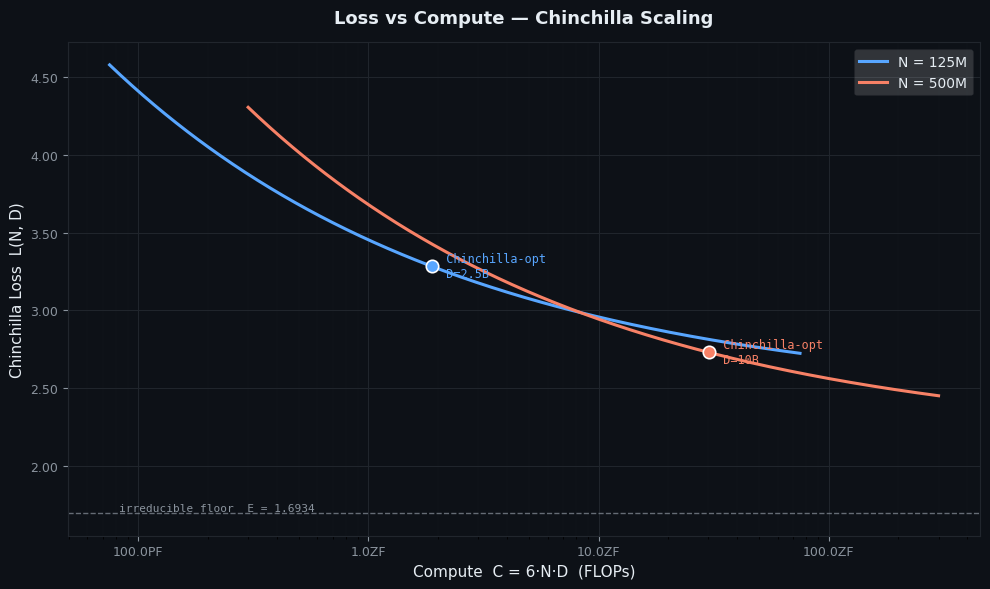

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Chinchilla constants (Hoffmann et al. 2022, Table A9, Approach 3) ─────────
A     = 406.4
alpha = 0.3392
B     = 410.7
beta  = 0.2849
E     = 1.6934

# ── Swap these ────────────────────────────────────────────────────────────────
N1 = 125e6    # params, model 1
N2 = 500e6      # params, model 2

D1 = 1e8      # token sweep start  (shared for both models)
D2 = 100e9    # token sweep end    (shared for both models)

N_POINTS = 500
# ─────────────────────────────────────────────────────────────────────────────


def chinchilla_loss(N, D):
    return A / N**alpha + B / D**beta + E


def fmt_params(n):
    if n >= 1e9:
        return f"{n/1e9:.3g}B"
    if n >= 1e6:
        return f"{n/1e6:.3g}M"
    return str(n)


def fmt_compute(c):
    """Human-readable FLOPs label."""
    for val, suffix in [(1e18, "ZF"), (1e15, "PF"), (1e12, "TF"), (1e9, "GF")]:
        if c >= val:
            return f"{c/val:.1f}{suffix}"
    return str(c)


# ── Compute ───────────────────────────────────────────────────────────────────
D_range  = np.logspace(np.log10(D1), np.log10(D2), N_POINTS)

C1 = 6 * N1 * D_range
L1 = chinchilla_loss(N1, D_range)

C2 = 6 * N2 * D_range
L2 = chinchilla_loss(N2, D_range)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

COLOR1 = "#58a6ff"   # blue  — small model
COLOR2 = "#f78166"   # coral — large model
GRID   = "#21262d"
TEXT   = "#e6edf3"
MUTED  = "#8b949e"

ax.plot(C1, L1, color=COLOR1, linewidth=2.2, label=f"N = {fmt_params(N1)}")
ax.plot(C2, L2, color=COLOR2, linewidth=2.2, label=f"N = {fmt_params(N2)}")

# Chinchilla-optimal markers (D_opt = 20*N)
for N, C_arr, L_arr, color in [(N1, C1, L1, COLOR1), (N2, C2, L2, COLOR2)]:
    D_opt   = 20 * N
    C_opt   = 6 * N * D_opt
    L_opt   = chinchilla_loss(N, D_opt)
    # find nearest index
    idx = np.argmin(np.abs(D_range - D_opt))
    ax.scatter([C_arr[idx]], [L_arr[idx]], s=80, color=color,
               edgecolors="white", linewidths=1.2, zorder=5)
    ax.annotate(f"  Chinchilla-opt\n  D={fmt_params(D_opt)}",
                xy=(C_arr[idx], L_arr[idx]),
                color=color, fontsize=8.5, va="center",
                fontfamily="monospace")

# Irreducible loss floor
ax.axhline(E, color=MUTED, linewidth=1, linestyle="--", alpha=0.7)
ax.text(C1.min() * 1.1, E + 0.015, f"irreducible floor  E = {E}",
        color=MUTED, fontsize=8, fontfamily="monospace")

# Styling
ax.set_xscale("log")
ax.set_xlabel("Compute  C = 6·N·D  (FLOPs)", color=TEXT, fontsize=11)
ax.set_ylabel("Chinchilla Loss  L(N, D)", color=TEXT, fontsize=11)
ax.set_title("Loss vs Compute — Chinchilla Scaling", color=TEXT,
             fontsize=13, fontweight="bold", pad=14)

ax.tick_params(colors=MUTED, labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: fmt_compute(x)
))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

ax.grid(True, which="both", color=GRID, linewidth=0.7, linestyle="-")
ax.grid(True, which="minor", color=GRID, linewidth=0.3, linestyle=":")

legend = ax.legend(fontsize=10, framealpha=0.15, edgecolor=GRID,
                   labelcolor=TEXT, loc="upper right")

plt.tight_layout()
plt.savefig("chinchilla_loss_plot.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved: chinchilla_loss_plot.png")
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Empirical overlay: load training logs and add them to the Chinchilla figure
# ---------------------------------------------------------------------------
# Run this cell after at least one model has finished training.
# It reads the loss_log.csv files produced by experiments/chinchilla/train.py
# and overlays the empirical curves on the existing Chinchilla scaling figure.
#
# Expected CSV columns:
#   step, tokens_seen, cumulative_flops, train_loss, eval_loss
#
# Usage: just run this cell; it will silently skip missing log files.
# ---------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# --- paths ------------------------------------------------------------------
NOTEBOOK_DIR  = Path(".")            # assumes notebook is run from repo root
RESULTS_ROOT  = NOTEBOOK_DIR / "experiments" / "chinchilla" / "results"
PLOTS_DIR     = NOTEBOOK_DIR / "experiments" / "chinchilla" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Chinchilla constants (same as cell 1) ----------------------------------
A     = 406.4
alpha = 0.3392
B     = 410.7
beta  = 0.2849
E     = 1.6934

def chinchilla_loss(N, D):
    return A / N**alpha + B / D**beta + E

# --- Model registry (matches model_configs.py) ------------------------------
MODELS = {
    "model1_125m": {
        "label": "125M standard",
        "color": "#58a6ff",
        "n_params": 50_257 * 768 + 12 * 12 * 768**2,
        "averaging_k": 1,
    },
    "model2_500m": {
        "label": "500M standard",
        "color": "#f78166",
        "n_params": 50_257 * 1024 + 36 * 12 * 1024**2,
        "averaging_k": 1,
    },
    "avg_125m_k2": {
        "label": "125M + 2× averaging",
        "color": "#3fb950",
        "n_params": 50_257 * 768 + 12 * 12 * 768**2,
        "averaging_k": 2,
    },
}

# --- EMA smoothing ----------------------------------------------------------
def ema_smooth(values, alpha_ema=0.9):
    smoothed = np.zeros_like(values, dtype=float)
    if len(values) == 0:
        return smoothed
    smoothed[0] = values[0]
    for i in range(1, len(values)):
        smoothed[i] = alpha_ema * smoothed[i-1] + (1 - alpha_ema) * values[i]
    return smoothed

# --- Load available logs ---------------------------------------------------
logs = {}
for name in MODELS:
    csv_path = RESULTS_ROOT / name / "loss_log.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["cumulative_flops"] = df["cumulative_flops"].astype(float)
        logs[name] = df
        print(f"Loaded {name}: {len(df)} rows, "
              f"max_flops={df['cumulative_flops'].max():.2e}")
    else:
        print(f"[skip] {csv_path} not found yet")

# --- Build FLOPs axis for theoretical curves --------------------------------
all_flops = []
for df in logs.values():
    all_flops.extend(df["cumulative_flops"].tolist())

flops_min = min(all_flops) * 0.5 if all_flops else 1e15
flops_max = max(all_flops) * 2.0 if all_flops else 4e19
C_axis = np.geomspace(flops_min, flops_max, 400)

# --- Rebuild the base Chinchilla figure (reuse cell-1 constants) -----------
# We reconstruct the full figure here so the empirical curves appear in
# the same coordinate system as the theoretical ones.

fig_combined = go.Figure()

for name, info in MODELS.items():
    N     = info["n_params"]
    k     = info["averaging_k"]
    color = info["color"]
    label = info["label"]

    # Theoretical: D effective = C / (6·N / k)  — averaging halves the compute
    divisor = 6.0 / k
    theory_loss = np.array([
        chinchilla_loss(N, max(C / (divisor * N), 1e6))
        for C in C_axis
    ])
    fig_combined.add_trace(go.Scatter(
        x=C_axis.tolist(), y=theory_loss.tolist(),
        mode="lines",
        name=f"Chinchilla theory ({label})",
        line=dict(color=color, width=1.8, dash="dot"),
        opacity=0.4,
        hovertemplate="C = %{x:.3e}<br>L = %{y:.4f}<extra></extra>",
    ))

    # Chinchilla-optimal point: D* = 20·N, C* = divisor·N·D*
    D_opt = 20.0 * N
    C_opt = divisor * N * D_opt
    L_opt = chinchilla_loss(N, D_opt)
    fig_combined.add_trace(go.Scatter(
        x=[C_opt], y=[L_opt],
        mode="markers",
        name=f"Chinchilla-opt ({label})",
        marker=dict(color=color, size=12,
                    line=dict(color="white", width=1.5), symbol="circle"),
        hovertemplate=f"Chinchilla-opt {label}<br>C=%{{x:.3e}}<br>L=%{{y:.4f}}<extra></extra>",
    ))

# --- Overlay empirical curves ----------------------------------------------
for name, df in logs.items():
    info  = MODELS[name]
    color = info["color"]
    label = info["label"]

    flops      = df["cumulative_flops"].values
    train_loss = ema_smooth(df["train_loss"].values, alpha_ema=0.9)
    eval_loss  = df["eval_loss"].values

    fig_combined.add_trace(go.Scatter(
        x=flops.tolist(), y=train_loss.tolist(),
        mode="lines",
        name=f"{label} train (empirical)",
        line=dict(color=color, width=2.8),
        hovertemplate="C = %{x:.3e}<br>train loss = %{y:.4f}<extra></extra>",
    ))

    eval_mask = ~np.isnan(eval_loss)
    if eval_mask.any():
        fig_combined.add_trace(go.Scatter(
            x=flops[eval_mask].tolist(), y=eval_loss[eval_mask].tolist(),
            mode="lines+markers",
            name=f"{label} eval (empirical)",
            line=dict(color=color, width=1.8, dash="dash"),
            marker=dict(size=5),
            hovertemplate="C = %{x:.3e}<br>eval loss = %{y:.4f}<extra></extra>",
        ))

# --- Irreducible floor annotation ------------------------------------------
fig_combined.add_hline(
    y=E,
    line=dict(color="#8b949e", width=1, dash="longdash"),
    annotation_text=f"irreducible floor  E = {E}",
    annotation_position="bottom right",
    annotation_font=dict(color="#8b949e", size=11),
)

fig_combined.update_layout(
    template="plotly_dark",
    paper_bgcolor="#0d1117",
    plot_bgcolor="#161b22",
    title=dict(
        text=(
            "Token Averaging vs. Standard OLM — Loss vs. FLOPs<br>"
            "<sub>Solid = empirical train (EMA-smoothed) · Dashed = empirical eval · "
            "Dotted = Chinchilla theory · ● = Chinchilla-optimal</sub>"
        ),
        font=dict(size=17, color="#e6edf3"),
    ),
    xaxis=dict(
        title="Cumulative FLOPs", type="log",
        gridcolor="#21262d",
        tickfont=dict(color="#c9d1d9"),
        titlefont=dict(color="#c9d1d9"),
    ),
    yaxis=dict(
        title="Cross-Entropy Loss",
        gridcolor="#21262d",
        tickfont=dict(color="#c9d1d9"),
        titlefont=dict(color="#c9d1d9"),
    ),
    legend=dict(
        bgcolor="#161b22", bordercolor="#30363d", borderwidth=1,
        font=dict(color="#c9d1d9", size=11),
    ),
    hovermode="x unified",
    width=1150, height=680,
)

# Save standalone HTML
out_html = PLOTS_DIR / "loss_vs_flops_notebook.html"
fig_combined.write_html(str(out_html))
print(f"Saved interactive plot → {out_html}")

fig_combined.show()


Saved: chinchilla_loss_plot.png


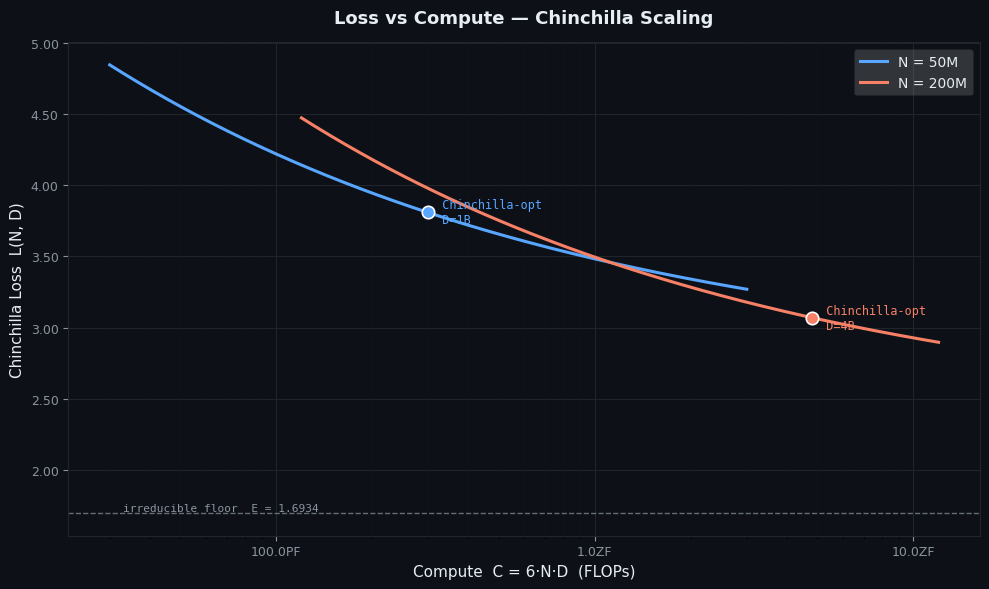

In [1]:
# LOWER MODELS

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Chinchilla constants (Hoffmann et al. 2022, Table A9, Approach 3) ─────────
A     = 406.4
alpha = 0.3392
B     = 410.7
beta  = 0.2849
E     = 1.6934

# ── Swap these ────────────────────────────────────────────────────────────────
N1 = 50e6    # params, model 1
N2 = 200e6      # params, model 2

D1 = 1e8      # token sweep start  (shared for both models)
D2 = 10e9    # token sweep end    (shared for both models)

N_POINTS = 500
# ─────────────────────────────────────────────────────────────────────────────


def chinchilla_loss(N, D):
    return A / N**alpha + B / D**beta + E


def fmt_params(n):
    if n >= 1e9:
        return f"{n/1e9:.3g}B"
    if n >= 1e6:
        return f"{n/1e6:.3g}M"
    return str(n)


def fmt_compute(c):
    """Human-readable FLOPs label."""
    for val, suffix in [(1e18, "ZF"), (1e15, "PF"), (1e12, "TF"), (1e9, "GF")]:
        if c >= val:
            return f"{c/val:.1f}{suffix}"
    return str(c)


# ── Compute ───────────────────────────────────────────────────────────────────
D_range  = np.logspace(np.log10(D1), np.log10(D2), N_POINTS)

C1 = 6 * N1 * D_range
L1 = chinchilla_loss(N1, D_range)

C2 = 6 * N2 * D_range
L2 = chinchilla_loss(N2, D_range)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

COLOR1 = "#58a6ff"   # blue  — small model
COLOR2 = "#f78166"   # coral — large model
GRID   = "#21262d"
TEXT   = "#e6edf3"
MUTED  = "#8b949e"

ax.plot(C1, L1, color=COLOR1, linewidth=2.2, label=f"N = {fmt_params(N1)}")
ax.plot(C2, L2, color=COLOR2, linewidth=2.2, label=f"N = {fmt_params(N2)}")

# Chinchilla-optimal markers (D_opt = 20*N)
for N, C_arr, L_arr, color in [(N1, C1, L1, COLOR1), (N2, C2, L2, COLOR2)]:
    D_opt   = 20 * N
    C_opt   = 6 * N * D_opt
    L_opt   = chinchilla_loss(N, D_opt)
    # find nearest index
    idx = np.argmin(np.abs(D_range - D_opt))
    ax.scatter([C_arr[idx]], [L_arr[idx]], s=80, color=color,
               edgecolors="white", linewidths=1.2, zorder=5)
    ax.annotate(f"  Chinchilla-opt\n  D={fmt_params(D_opt)}",
                xy=(C_arr[idx], L_arr[idx]),
                color=color, fontsize=8.5, va="center",
                fontfamily="monospace")

# Irreducible loss floor
ax.axhline(E, color=MUTED, linewidth=1, linestyle="--", alpha=0.7)
ax.text(C1.min() * 1.1, E + 0.015, f"irreducible floor  E = {E}",
        color=MUTED, fontsize=8, fontfamily="monospace")

# Styling
ax.set_xscale("log")
ax.set_xlabel("Compute  C = 6·N·D  (FLOPs)", color=TEXT, fontsize=11)
ax.set_ylabel("Chinchilla Loss  L(N, D)", color=TEXT, fontsize=11)
ax.set_title("Loss vs Compute — Chinchilla Scaling", color=TEXT,
             fontsize=13, fontweight="bold", pad=14)

ax.tick_params(colors=MUTED, labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: fmt_compute(x)
))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

ax.grid(True, which="both", color=GRID, linewidth=0.7, linestyle="-")
ax.grid(True, which="minor", color=GRID, linewidth=0.3, linestyle=":")

legend = ax.legend(fontsize=10, framealpha=0.15, edgecolor=GRID,
                   labelcolor=TEXT, loc="upper right")

plt.tight_layout()
plt.savefig("chinchilla_loss_plot.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved: chinchilla_loss_plot.png")
plt.show()

In [2]:
import numpy as np
import plotly.graph_objects as go

# ── Chinchilla constants (Hoffmann et al. 2022, Table A9, Approach 3) ─────────
A = 406.4
alpha = 0.3392
B = 410.7
beta = 0.2849
E = 1.6934

# ── Swap these ────────────────────────────────────────────────────────────────
N1 = 50e6  # params, model 1
N2 = 200e6  # params, model 2

D1 = 1e8   # token sweep start
D2 = 100e9  # token sweep end

N_POINTS = 500
# ─────────────────────────────────────────────────────────────────────────────


def chinchilla_loss(N, D):
    return A / N**alpha + B / D**beta + E


def fmt_params(n):
    if n >= 1e9:
        return f"{n/1e9:.3g}B"
    if n >= 1e6:
        return f"{n/1e6:.3g}M"
    return str(n)


# ── Compute curves ────────────────────────────────────────────────────────────
D_range = np.logspace(np.log10(D1), np.log10(D2), N_POINTS)

C1 = 6 * N1 * D_range
L1 = chinchilla_loss(N1, D_range)

C2 = 6 * N2 * D_range
L2 = chinchilla_loss(N2, D_range)

# ── Chinchilla-opt for N1 ─────────────────────────────────────────────────────
D_opt1 = 20 * N1
C_opt1 = 6 * N1 * D_opt1
L_opt1 = chinchilla_loss(N1, D_opt1)

# ── Equivalent point on N2 at the same loss ───────────────────────────────────
# Solve A/N2**α + B/D_eq**β + E = L_opt1  →  D_eq = (B / (L_opt1 - E - A/N2**α))^(1/β)
D_eq2 = (B / (L_opt1 - E - A / N2**alpha)) ** (1 / beta)
C_eq2 = 6 * N2 * D_eq2
L_eq2 = chinchilla_loss(N2, D_eq2)

delta_C = C_eq2 - C_opt1

# ── Chinchilla-opt for N2 (independent marker) ────────────────────────────────
D_opt2 = 20 * N2
C_opt2 = 6 * N2 * D_opt2
L_opt2 = chinchilla_loss(N2, D_opt2)

# ── Colors ────────────────────────────────────────────────────────────────────
COLOR1 = "#58a6ff"
COLOR2 = "#f78166"
MUTED  = "#8b949e"
BG     = "#0d1117"
TEXT   = "#e6edf3"
GRID   = "#21262d"

# ── Build figure ──────────────────────────────────────────────────────────────
fig = go.Figure()

# Loss curves
fig.add_trace(go.Scatter(
    x=C1, y=L1, mode="lines", name=f"N = {fmt_params(N1)}",
    line=dict(color=COLOR1, width=2.5),
    hovertemplate="C = %{x:.3e}<br>L = %{y:.4f}<extra>N={fmt_params(N1)}</extra>",
))
fig.add_trace(go.Scatter(
    x=C2, y=L2, mode="lines", name=f"N = {fmt_params(N2)}",
    line=dict(color=COLOR2, width=2.5),
    hovertemplate="C = %{x:.3e}<br>L = %{y:.4f}<extra>N={fmt_params(N2)}</extra>",
))

# Chinchilla-opt marker — N1
fig.add_trace(go.Scatter(
    x=[C_opt1], y=[L_opt1], mode="markers",
    name=f"Chinchilla-opt N1  (D={fmt_params(D_opt1)})",
    marker=dict(color=COLOR1, size=11, line=dict(color="white", width=1.5)),
    hovertemplate=f"Chinchilla-opt N1<br>C = %{{x:.3e}}<br>L = %{{y:.4f}}<br>D = {fmt_params(D_opt1)}<extra></extra>",
))

# Horizontal dashed line at L_opt1
fig.add_shape(
    type="line",
    x0=C_opt1, x1=C_eq2, y0=L_opt1, y1=L_opt1,
    line=dict(color=COLOR1, width=1.5, dash="dot"),
)

# Equivalent point on N2
fig.add_trace(go.Scatter(
    x=[C_eq2], y=[L_eq2], mode="markers",
    name=f"Equivalent on N2  (D={fmt_params(D_eq2)})",
    marker=dict(color=COLOR2, size=11, symbol="diamond", line=dict(color="white", width=1.5)),
    hovertemplate=f"Equivalent on N2<br>C = %{{x:.3e}}<br>L = %{{y:.4f}}<br>D = {fmt_params(D_eq2)}<extra></extra>",
))

# Chinchilla-opt marker — N2
fig.add_trace(go.Scatter(
    x=[C_opt2], y=[L_opt2], mode="markers",
    name=f"Chinchilla-opt N2  (D={fmt_params(D_opt2)})",
    marker=dict(color=COLOR2, size=11, line=dict(color="white", width=1.5)),
    hovertemplate=f"Chinchilla-opt N2<br>C = %{{x:.3e}}<br>L = %{{y:.4f}}<br>D = {fmt_params(D_opt2)}<extra></extra>",
))

# ΔCompute annotation between the two horizontal points
x_mid = np.sqrt(C_opt1 * C_eq2)  # geometric mean looks better on log axis
# fig.add_annotation(
#     x=np.log10(x_mid), y=L_opt1 + 0.04,
#     xref="x", yref="y",
#     text=f"<b>ΔC = {delta_C:.3e} FLOPs</b><br>({C_eq2/C_opt1:.2f}× more compute for N2)",
#     showarrow=False,
#     font=dict(color=TEXT, size=11),
#     bgcolor="rgba(13,17,23,0.75)",
#     bordercolor=COLOR1,
#     borderwidth=1,
#     borderpad=5,
# )

# Irreducible floor
fig.add_hline(
    y=E, line=dict(color=MUTED, width=1, dash="dash"),
    annotation_text=f"irreducible floor  E = {E}",
    annotation_font_color=MUTED,
    annotation_position="bottom right",
)

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    title=dict(text="Loss vs Compute — Chinchilla Scaling", font=dict(size=15, color=TEXT)),
    xaxis=dict(
        type="log",
        title="Compute  C = 6·N·D  (FLOPs)",
        gridcolor=GRID, showgrid=True, minor=dict(showgrid=True, gridcolor=GRID),
        tickformat=".0e",
    ),
    yaxis=dict(
        title="Chinchilla Loss  L(N, D)",
        gridcolor=GRID, showgrid=True,
        tickformat=".2f",
    ),
    legend=dict(bgcolor="rgba(0,0,0,0.4)", bordercolor=GRID, borderwidth=1),
    hovermode="closest",
    width=950, height=580,
)

fig.show()

print(f"\nChinchilla-opt  N1 : C = {C_opt1:.3e} FLOPs,  L = {L_opt1:.4f},  D = {fmt_params(D_opt1)}")
print(f"Equivalent on   N2 : C = {C_eq2:.3e} FLOPs,  L = {L_eq2:.4f},  D = {fmt_params(D_eq2)}")
print(f"\nΔ Compute          : {delta_C:.3e} FLOPs  ({C_eq2/C_opt1:.2f}× more compute needed for N2 to reach the same loss)")



Chinchilla-opt  N1 : C = 3.000e+17 FLOPs,  L = 3.8081,  D = 1B
Equivalent on   N2 : C = 4.377e+17 FLOPs,  L = 3.8081,  D = 365M

Δ Compute          : 1.377e+17 FLOPs  (1.46× more compute needed for N2 to reach the same loss)
